# 07 — Nos données terrain Hanoï

**Le maillon entre la collecte (ODK/Kobo) et le modèle (notebook 08).**

Ce notebook fait tout le travail sur NOS données :
1. Charge l'export CSV de KoboToolbox
2. Nettoie (même pipeline que le notebook 02 sur Sunbird)
3. Enrichit avec la météo (API Open-Meteo, gratuite)
4. Analyses de la Phase 3 du plan : time-series par site, transport vs chantier, dépassements de normes
5. Sauvegarde `data/raw/hanoi/measurements.csv` → consommé par le notebook 08

**Comment exporter depuis Kobo :** ton projet → Data → Downloads → CSV → place le fichier dans `data/raw/hanoi/`

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../scripts'))
import prepare_field_data as pfd   # source de vérité unique du nettoyage terrain

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Charge l'export Kobo le plus récent → nettoyage + backfill + météo (cf. le script).
# Le brut Kobo n'est pas modifié ; tout le travail est en mémoire.
df = pfd.build_dataframe()
print(f'{len(df)} mesures propres — sites : {df["site"].value_counts().to_dict()}')
df[['timestamp', 'site', 'collector', 'noise_dB', 'dist_to_road', 'mic_to_source']].head()

/Users/phocidae/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


107 mesures propres — sites : {'Ocean Park': 91, 'Hoan Kiem lake': 16}


,timestamp,site,collector,noise_dB,dist_to_road,mic_to_source
0,2026-06-10 14:33:42.770,Ocean Park,lucas,75.0,0-10 m,towards
1,2026-06-10 21:38:50.850,Ocean Park,lucas,70.0,10-30 m,towards
2,2026-06-11 10:53:59.687,Ocean Park,lucas,65.0,10-30 m,towards
3,2026-06-11 10:59:08.473,Ocean Park,lucas,70.0,0-10 m,towards
4,2026-06-11 11:16:15.198,Ocean Park,lucas,65.0,10-30 m,towards


## Météo

La météo (Open-Meteo) est ajoutée automatiquement par `pfd.build_dataframe()` —
colonnes `temperature_2m`, `wind_speed_10m`, `precipitation` quand l'API répond.

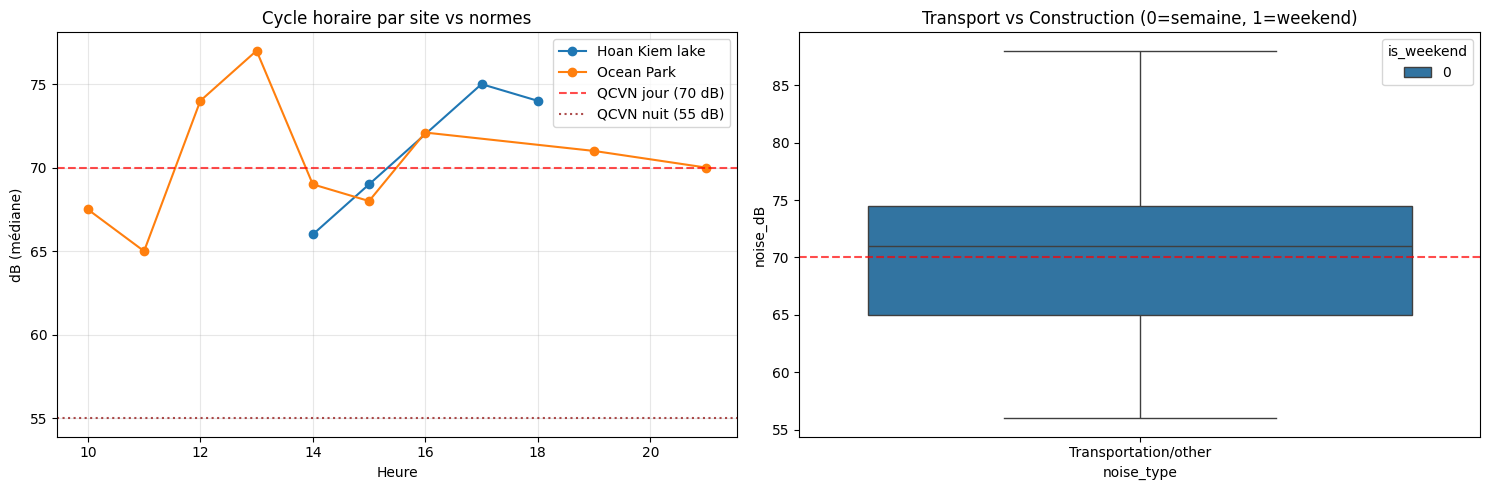

In [2]:
# Time-series par site : cycle horaire (médiane + IQR, comme la Fig. 9 du papier)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for site, g in df.groupby('site'):
    h = g.groupby('hour')['noise_dB'].median()
    axes[0].plot(h.index, h.values, marker='o', label=site)
axes[0].axhline(70, color='red', linestyle='--', alpha=0.7, label='QCVN jour (70 dB)')
axes[0].axhline(55, color='darkred', linestyle=':', alpha=0.7, label='QCVN nuit (55 dB)')
axes[0].set_xlabel('Heure'); axes[0].set_ylabel('dB (médiane)')
axes[0].set_title('Cycle horaire par site vs normes')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Transport vs construction (demandé par le plan)
df['noise_type'] = np.where(df['class'] == 'construction_site', 'Construction', 'Transportation/other')
sns.boxplot(data=df, x='noise_type', y='noise_dB', hue='is_weekend', ax=axes[1])
axes[1].axhline(70, color='red', linestyle='--', alpha=0.7)
axes[1].set_title('Transport vs Construction (0=semaine, 1=weekend)')

plt.tight_layout()
plt.savefig('../outputs/maps/hanoi_phase3_analysis.png', dpi=150)
plt.show()

In [3]:
# Dépassements de normes : fréquence et sévérité (demandé par le plan)
df['period'] = np.where((df['hour'] >= 21) | (df['hour'] < 6), 'night', 'day')
df['qcvn_limit'] = np.where(df['period'] == 'day', 70, 55)
df['exceeds_qcvn'] = df['noise_dB'] > df['qcvn_limit']
df['exceed_by'] = (df['noise_dB'] - df['qcvn_limit']).clip(lower=0)

summary = df.groupby(['site', 'period']).agg(
    n=('noise_dB', 'count'),
    median_dB=('noise_dB', 'median'),
    pct_exceed=('exceeds_qcvn', lambda x: 100 * x.mean()),
    mean_exceed_dB=('exceed_by', lambda x: x[x > 0].mean()),
).round(1)
print('=== Dépassements QCVN 26:2010/BTNMT par site ===')
print(summary)
summary.to_csv('../outputs/hanoi_exceedances.csv')

=== Dépassements QCVN 26:2010/BTNMT par site ===
                        n  median_dB  pct_exceed  mean_exceed_dB
site           period                                           
Hoan Kiem lake day     16       73.0        62.5             5.4
Ocean Park     day     90       70.5        50.0             4.9
               night    1       70.0       100.0            15.0


In [4]:
# ---- Sauvegarde finale : input du notebook 08 (calibration du modèle) ----
out = pfd.save_measurements(df)
print(f'{len(df)} mesures → {out}')
print('Prochaine étape : notebook 08 (transfer learning + carte de bruit)')

107 mesures → /Users/phocidae/Desktop/VinUni/noise-modelling-hanoi/data/raw/hanoi/measurements.csv
Prochaine étape : notebook 08 (transfer learning + carte de bruit)


In [5]:
# Carte des points de mesure (fond OpenStreetMap)
import folium

m = folium.Map(location=[df.latitude.mean(), df.longitude.mean()],
               zoom_start=16, tiles='OpenStreetMap')

def color(db):
    return 'green' if db < 60 else 'orange' if db < 70 else 'red' if db < 80 else 'darkred'

for _, r in df.iterrows():
    folium.CircleMarker(
        [r.latitude, r.longitude], radius=7,
        color=color(r.noise_dB), fill=True, fill_opacity=0.9,
        popup=f"{r.noise_dB:.0f} dB — {r['class']}<br>{r.timestamp:%d/%m %H:%M} — {r.collector}",
        tooltip=f'{r.noise_dB:.0f} dB',
    ).add_to(m)

legend = '''<div style="position:fixed;bottom:20px;left:20px;z-index:9999;background:white;
padding:10px;border:1px solid #888;border-radius:6px;font-size:13px">
<b>Mesures terrain (n=%d)</b><br>
<span style="color:green">&#9679;</span> &lt; 60 dB &nbsp;
<span style="color:orange">&#9679;</span> 60-70 &nbsp;
<span style="color:red">&#9679;</span> 70-80 &nbsp;
<span style="color:darkred">&#9679;</span> &gt; 80</div>''' % len(df)
m.get_root().html.add_child(folium.Element(legend))
m.save('../outputs/maps/hanoi_field_points.html')
m